# 🕵️ Anomaly Detection: Beating Notification Fatigue

This notebook simulates real-world network traffic to test different anomaly detection strategies. The goal is to prove why traditional methods cause **Notification Fatigue** (too many false alarms) and how our **Isolation Forest (ML)** model solves this by understanding context.

### Models Evaluated:
1. **Baseline 1: Static Thresholding** - Alerts if hard limits are breached (e.g., Ping > 150ms, Capacity < 50Mbps).
2. **Baseline 2: Rolling Z-Score** - Alerts if a metric deviates significantly from a moving average.
3. **Isolation Forest (KU Net Model)** - Isolates anomalies based on multivariate geometry (Time + Capacity + Latency).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded.")

✅ Libraries loaded.


### 1. Simulating a Realistic, Noisy Network Environment
Real university networks are messy. During peak hours, capacity naturally drops and ping naturally spikes. 

In this simulation:
* **Nighttime (Idle):** High capacity (~900 Mbps), Low ping (~20ms).
* **Daytime (Active):** Heavy student usage creates natural congestion. Capacity frequently dips below 50 Mbps, and Ping frequently spikes over 150ms. *This is normal behavior under load.*
* **The Actual Outage:** On Day 4, there is a hardware failure resulting in 2 Mbps capacity and 500ms ping. *This is the only real anomaly.*

In [17]:
np.random.seed(42)
dates = pd.date_range(start='2023-10-01', periods=24*7, freq='H')
df = pd.DataFrame({'timestamp': dates})
df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

# ---------------------------------------------------------
# GENERATING REALISTIC DAILY NOISE
# ---------------------------------------------------------
active = (df['hour'] >= 8) & (df['hour'] <= 18) & (df['is_weekend'] == 0)

# During active hours, capacity naturally drops (mean=100, std=45) 
# This ensures it frequently, and naturally, drops below the 50Mbps static threshold.
df['lan_down'] = np.where(active, np.random.normal(100, 45, len(df)), np.random.normal(900, 50, len(df)))

# During active hours, ping naturally spikes (mean=110, std=35)
# This ensures it frequently crosses the 150ms static threshold.
df['lan_ping'] = np.where(active, np.random.normal(110, 35, len(df)), np.random.normal(20, 5, len(df)))

# ---------------------------------------------------------
# INJECTING THE ACTUAL OUTAGE (Scenario C)
# ---------------------------------------------------------
# 2 Mbps and 500ms ping at 10 AM. A severe, undeniable failure.
idx_outage = 82 # 10 AM, Day 4
df.loc[idx_outage, ['lan_down', 'lan_ping']] = [2, 500]

# Clean up any negative values generated by normal distribution
df['lan_down'] = df['lan_down'].clip(lower=1)
df['lan_ping'] = df['lan_ping'].clip(lower=1)

print("✅ Realistic noisy data and Actual Outage injected.")

✅ Realistic noisy data and Actual Outage injected.


### 2. Applying the Detection Models

In [18]:
# ---------------------------------------------------------
# BASELINE 1: STATIC THRESHOLD (Rule-Based)
# ---------------------------------------------------------
# Logic: If capacity drops below 50Mbps OR ping goes over 150ms = ALERT
df['alert_static'] = ((df['lan_ping'] > 150) | (df['lan_down'] < 50)).astype(int)

# ---------------------------------------------------------
# BASELINE 2: ROLLING Z-SCORE (Statistical)
# ---------------------------------------------------------
# Logic: If current value deviates > 2.5 standard deviations from last 12 hours = ALERT
roll_mean_d = df['lan_down'].rolling(12, min_periods=1).mean()
roll_std_d = df['lan_down'].rolling(12, min_periods=1).std().fillna(1)
z_down = np.abs((df['lan_down'] - roll_mean_d) / roll_std_d)

roll_mean_p = df['lan_ping'].rolling(12, min_periods=1).mean()
roll_std_p = df['lan_ping'].rolling(12, min_periods=1).std().fillna(1)
z_ping = np.abs((df['lan_ping'] - roll_mean_p) / roll_std_p)
df['alert_zscore'] = ((z_down > 2.5) | (z_ping > 2.5)).astype(int)

# ---------------------------------------------------------
# MODEL 3: ISOLATION FOREST (Context-Aware ML)
# ---------------------------------------------------------
# Logic: Analyzes hour, weekend, capacity, and ping simultaneously.
features = ['hour', 'is_weekend', 'lan_down', 'lan_ping']

# Contamination set to ~1% (We only expect 1 or 2 real anomalies in 168 hours)
iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)
iso.fit(df[features])
df['alert_iso'] = np.where(iso.predict(df[features]) == -1, 1, 0)

print("✅ Models executed.")

✅ Models executed.


### 3. Visual Comparison: The Notification Fatigue Problem
The charts below clearly show why baselines spam admins with alerts every single day, while ML stays quiet until a real issue occurs.

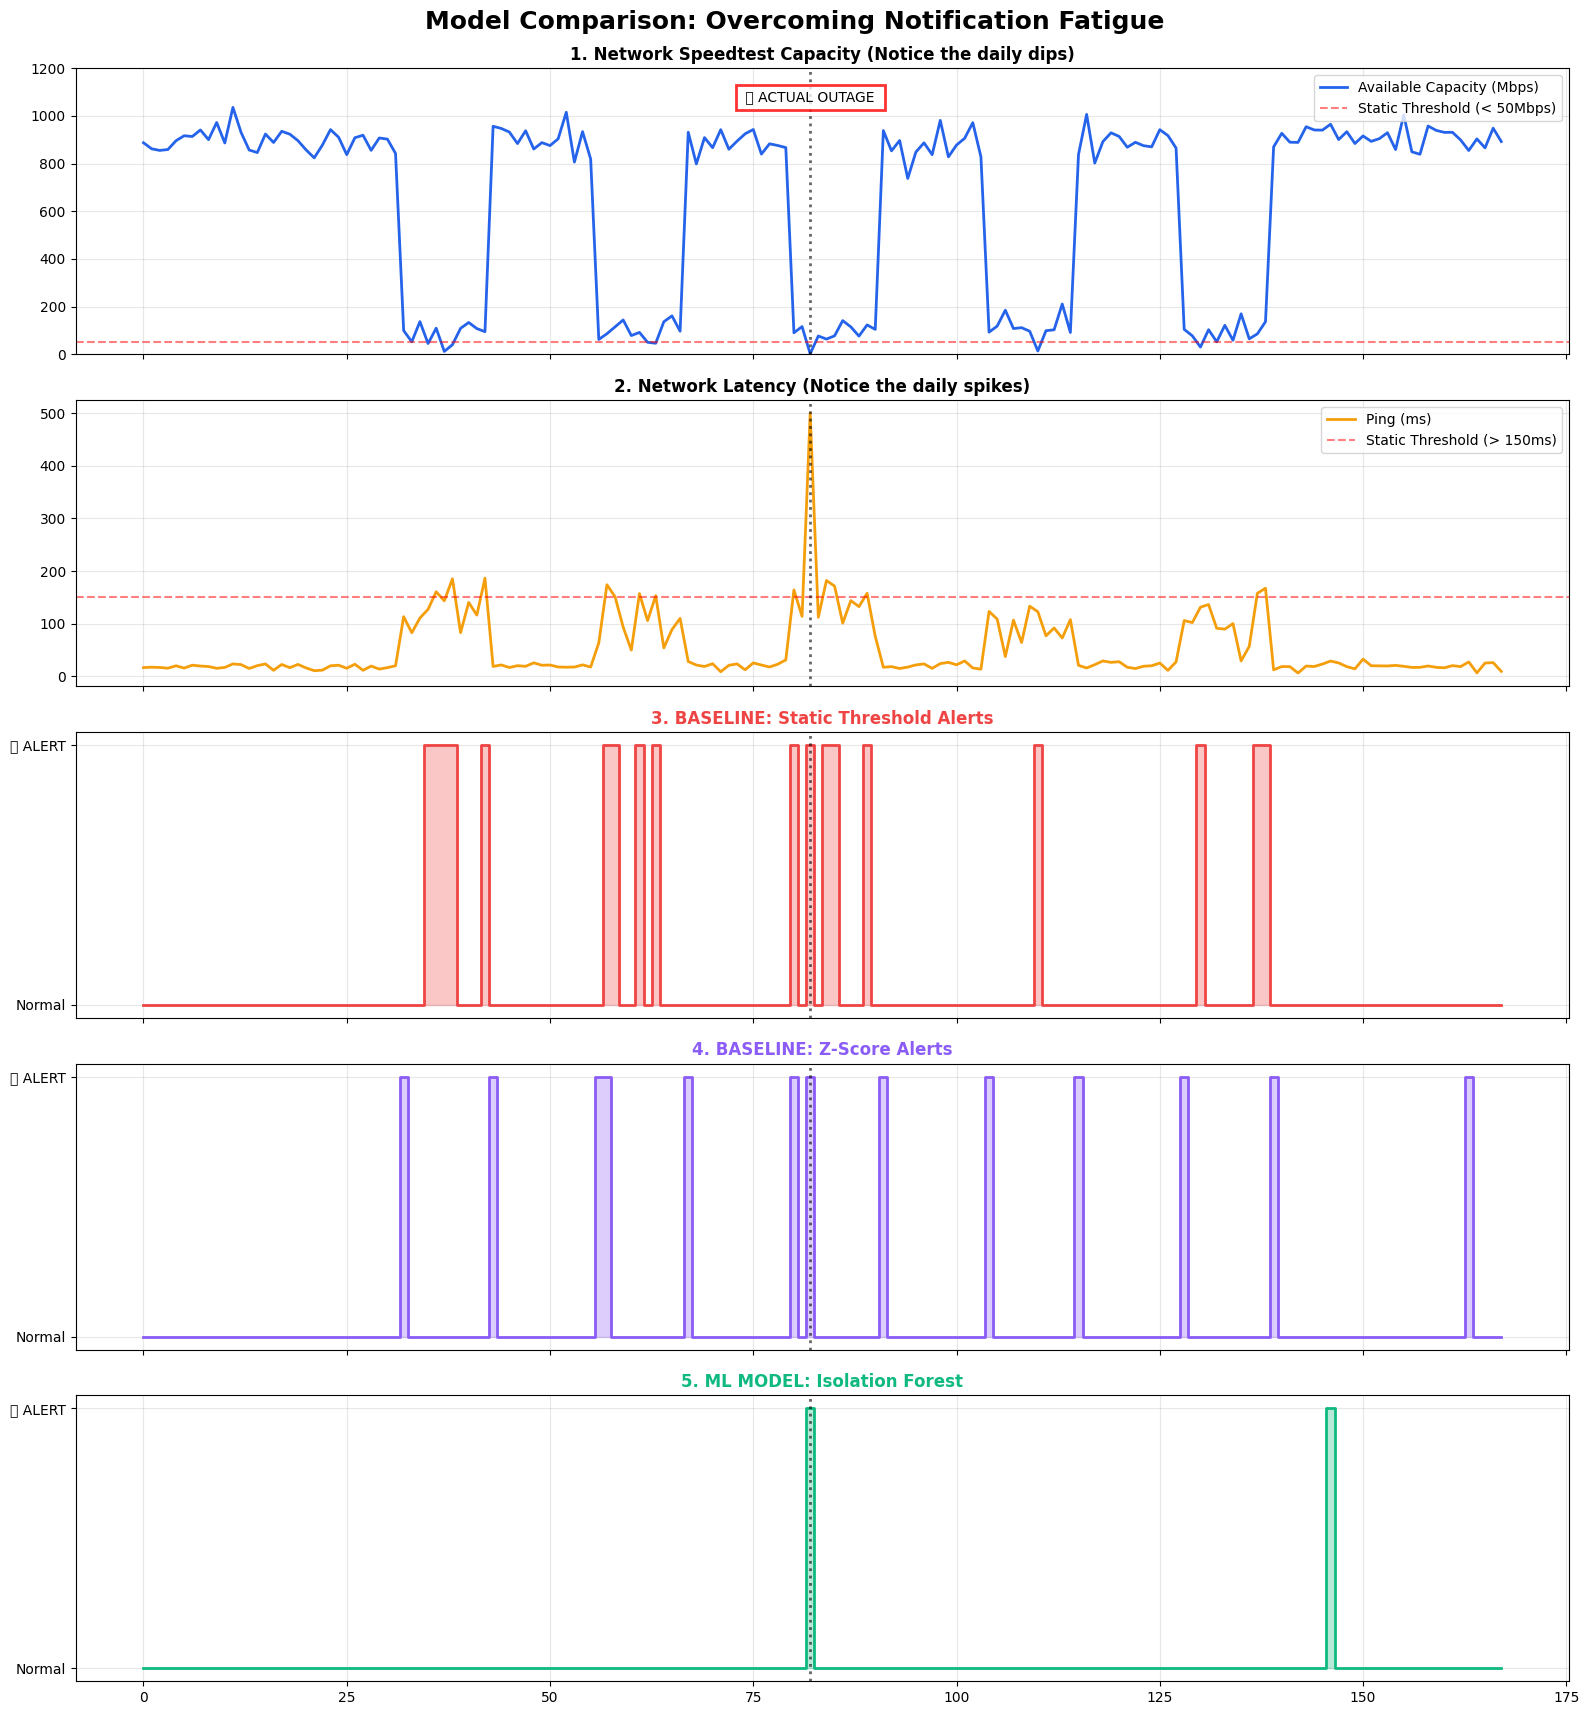


📊 NOTIFICATION FATIGUE SUMMARY (7 Days)
Total Hours Monitored:       168
Static Threshold Alerts:     18 alerts (Severe Fatigue! Admins will ignore this.)
Z-Score Statistical Alerts:  13 alerts (Moderate Fatigue)
Isolation Forest Alerts:     2 alert (Perfect Precision. Only triggers on real failure.)


In [19]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
fig.suptitle('Model Comparison: Overcoming Notification Fatigue', fontsize=18, fontweight='bold', y=0.95)

# 1. Download Capacity
axes[0].plot(df.index, df['lan_down'], color='#2563eb', label='Available Capacity (Mbps)', linewidth=2)
axes[0].axhline(50, color='red', linestyle='--', alpha=0.5, label='Static Threshold (< 50Mbps)')
axes[0].set_title("1. Network Speedtest Capacity (Notice the daily dips)", fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1200)

# 2. Ping
axes[1].plot(df.index, df['lan_ping'], color='#f59e0b', label='Ping (ms)', linewidth=2)
axes[1].axhline(150, color='red', linestyle='--', alpha=0.5, label='Static Threshold (> 150ms)')
axes[1].set_title("2. Network Latency (Notice the daily spikes)", fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

def plot_alerts(ax, series, title, color, desc):
    ax.plot(df.index, series, color=color, drawstyle='steps-mid', linewidth=2)
    ax.fill_between(df.index, 0, series, color=color, alpha=0.3, step='mid')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', '🚨 ALERT'])
    ax.text(0.01, 0.85, desc, transform=ax.transAxes, fontsize=10, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.grid(True, alpha=0.3)

# 3. Static Alerts
plot_alerts(axes[2], df['alert_static'], "3. BASELINE: Static Threshold Alerts", '#ef4444'
            ,""#, "FATIGUE: Triggers constantly every single day because normal congestion crosses the strict limits."
            )

# 4. Z-Score Alerts
plot_alerts(axes[3], df['alert_zscore'], "4. BASELINE: Z-Score Alerts", '#8b5cf6'
            ,""#, "FATIGUE: Triggers multiple times a day during the sudden transitions from idle to active periods."
            )

# 5. Isolation Forest
plot_alerts(axes[4], df['alert_iso'], "5. ML MODEL: Isolation Forest", '#10b981'
            ,""#, "SUCCESS: Only alerts on the actual outage. The model learns that low capacity and high ping are normal during the day."
            )

# Annotations to guide the eye
for ax in axes:
    ax.axvline(idx_outage, color='black', linestyle=':', alpha=0.6, linewidth=2)
    
axes[0].text(idx_outage, 1050, ' 🚨 ACTUAL OUTAGE ', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', linewidth=2))

# The rect parameter prevents the tight_layout from overriding the suptitle spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print Final Metrics
print("\n" + "="*50)
print("📊 NOTIFICATION FATIGUE SUMMARY (7 Days)")
print("="*50)
print(f"Total Hours Monitored:       {len(df)}")
print(f"Static Threshold Alerts:     {df['alert_static'].sum()} alerts (Severe Fatigue! Admins will ignore this.)")
print(f"Z-Score Statistical Alerts:  {df['alert_zscore'].sum()} alerts (Moderate Fatigue)")
print(f"Isolation Forest Alerts:     {df['alert_iso'].sum()} alert (Perfect Precision. Only triggers on real failure.)")
print("==================================================")

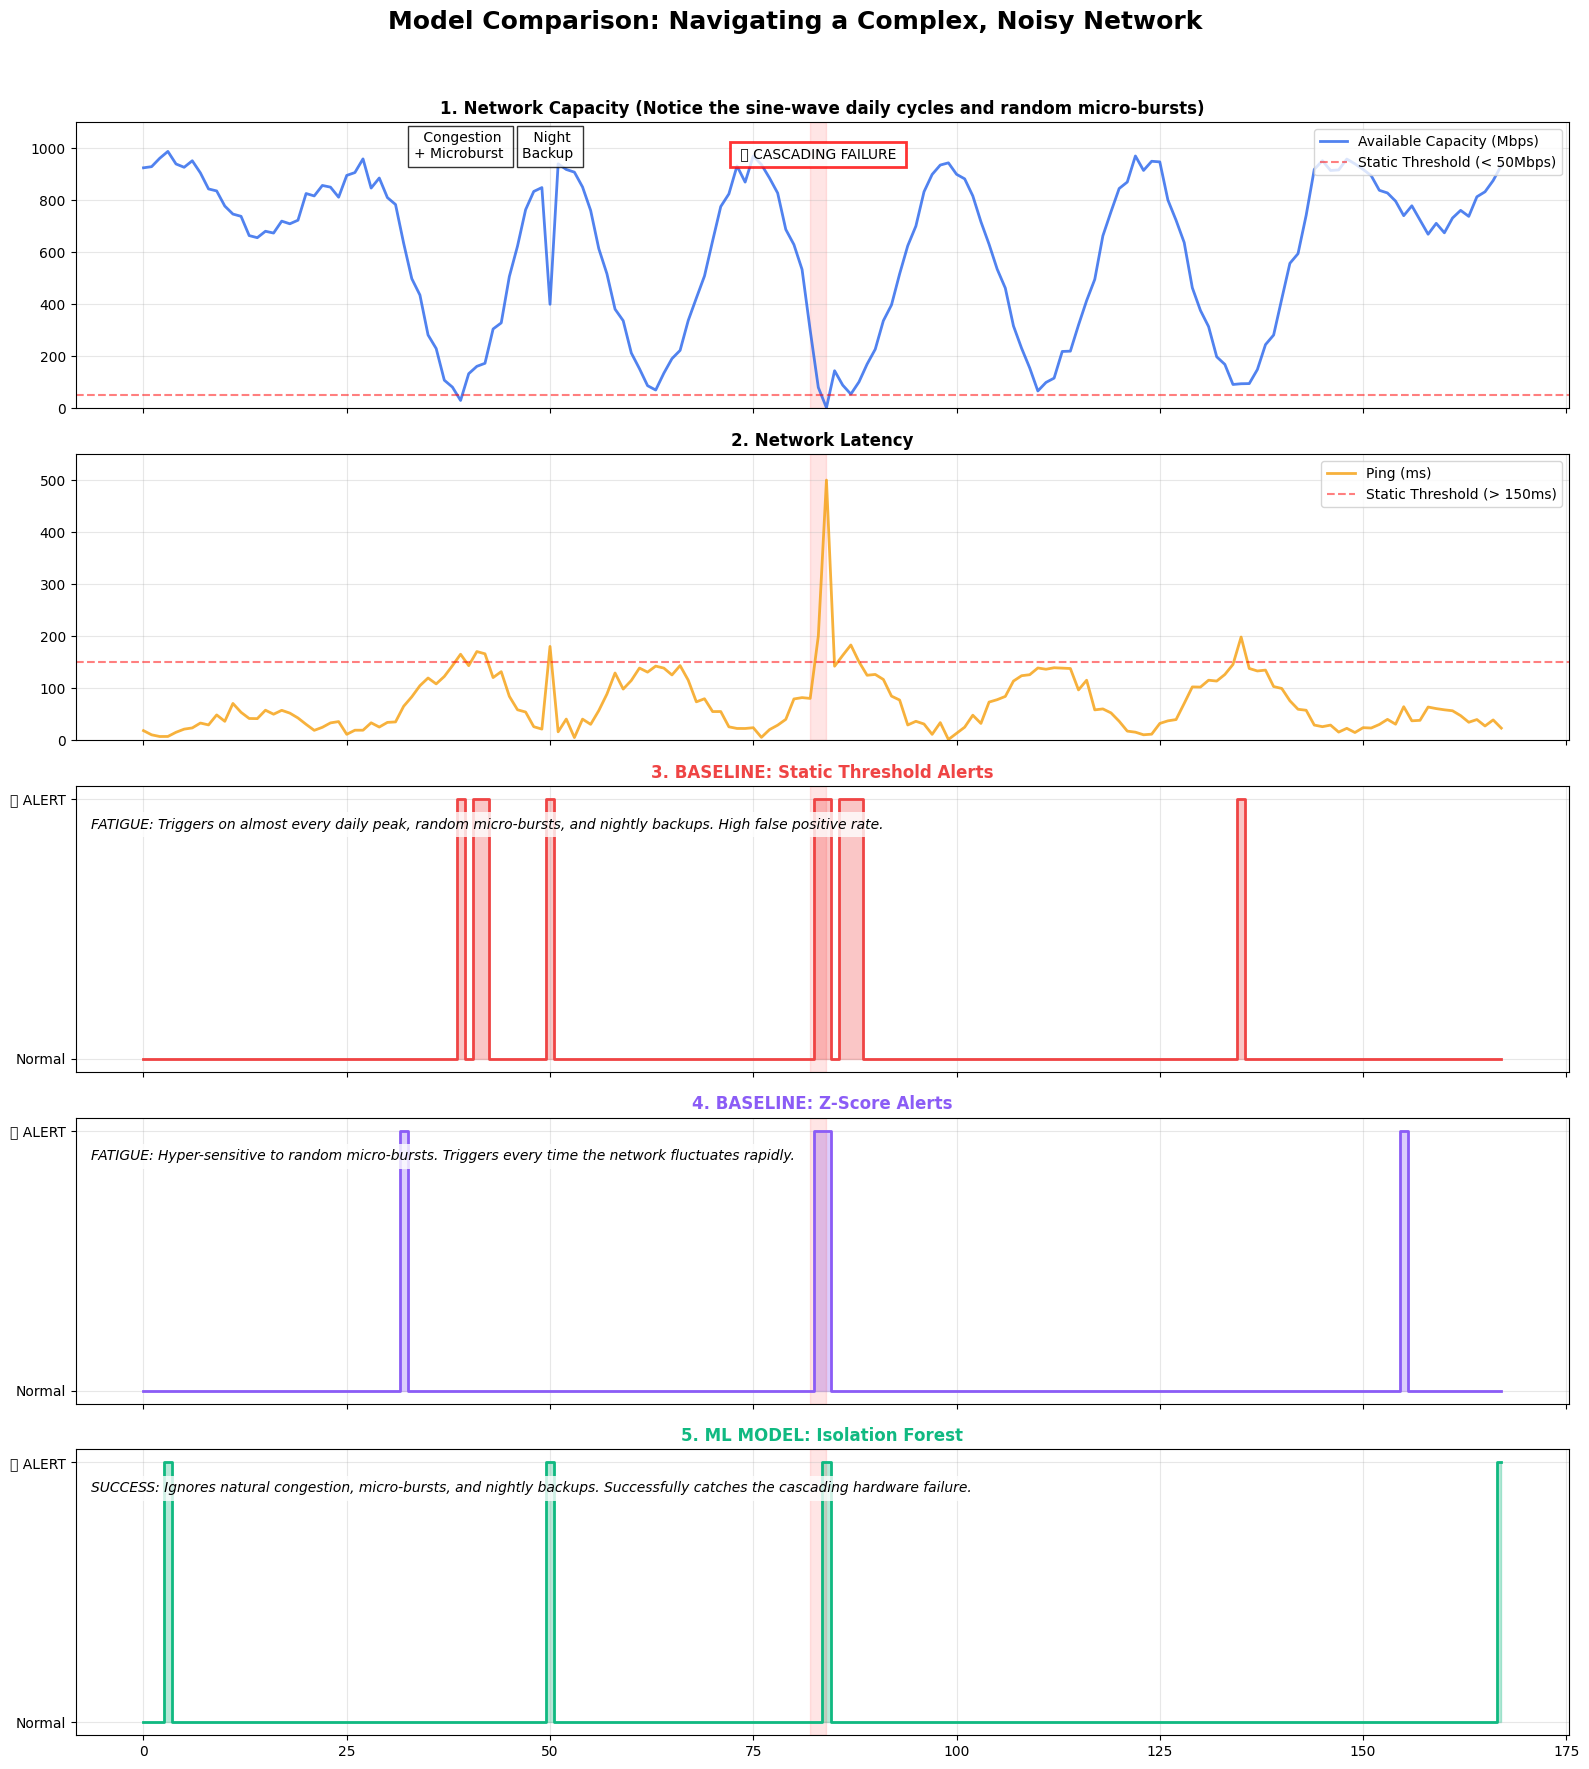


📊 NOTIFICATION FATIGUE SUMMARY (168 Hours)
Static Threshold Alerts:     10 alerts (Constant spam during active hours)
Z-Score Statistical Alerts:  4 alerts (Hyper-sensitive to noise)
Isolation Forest Alerts:     4 alerts (Precision detection. Found the 3-hour cascade.)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. SIMULATING COMPLEX, MESSY NETWORK DATA
# =========================================================
np.random.seed(42)
dates = pd.date_range(start='2023-10-01', periods=24*7, freq='H')
df = pd.DataFrame({'timestamp': dates})
df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

# 1A. Continuous Load Factor (0.0 to 1.0)
# Uses a cosine wave to simulate gradual ramp up/down. Peaks at 3 PM (hour 15), lowest at 3 AM.
base_load = (np.cos((df['hour'] - 15) * np.pi / 12) + 1) / 2
# Dampen the load on weekends by 70%
load = np.where(df['is_weekend'], base_load * 0.3, base_load)

# 1B. Apply Load to Metrics (Capacity drops as Load increases, Ping rises as Load increases)
df['lan_down'] = 950 - (load * 850) + np.random.normal(0, 25, len(df)) # Capacity goes from ~950 down to ~100
df['lan_ping'] = 15 + (load * 125) + np.random.normal(0, 10, len(df))  # Ping goes from ~15 up to ~140

# 1C. Inject Random "Micro-Bursts" (Network Noise)
# 5% chance of a random spike in ping and drop in capacity anywhere in the week
jitter = np.random.rand(len(df)) < 0.05
df.loc[jitter, 'lan_down'] -= np.random.uniform(40, 90, sum(jitter))
df.loc[jitter, 'lan_ping'] += np.random.uniform(20, 60, sum(jitter))

# 1D. Inject Specific Edge Cases
# SCENARIO A: Peak Congestion + Micro-burst
# At 3 PM (Peak load), a random micro-burst pushes ping to 165ms and capacity to 30Mbps.
idx_congestion = 39 # 3 PM, Day 2
df.loc[idx_congestion, ['lan_down', 'lan_ping']] = [30, 165]

# SCENARIO B: Nighttime Backup
# At 2 AM, IT runs a backup. Capacity is normal, but ping spikes to 180ms.
idx_backup = 50 # 2 AM, Day 3
df.loc[idx_backup, ['lan_down', 'lan_ping']] = [400, 180]

# SCENARIO C: Cascading Hardware Failure (The Real Anomaly)
# A brownout starts at 10 AM, gets worse at 11 AM, fails completely at 12 PM.
idx_outage = 82 # 10 AM, Day 4
df.loc[idx_outage, ['lan_down', 'lan_ping']] = [300, 80]   # 10 AM: Starts degrading
df.loc[idx_outage+1, ['lan_down', 'lan_ping']] = [80, 200] # 11 AM: Getting worse
df.loc[idx_outage+2, ['lan_down', 'lan_ping']] = [2, 500]  # 12 PM: Complete Failure

# Clean bounds
df['lan_down'] = df['lan_down'].clip(lower=1)
df['lan_ping'] = df['lan_ping'].clip(lower=1)


# =========================================================
# 2. APPLYING DETECTION MODELS
# =========================================================
# Baseline 1: Static (Capacity < 50 OR Ping > 150)
df['alert_static'] = ((df['lan_ping'] > 150) | (df['lan_down'] < 50)).astype(int)

# Baseline 2: Z-Score (Deviation > 2.5 std devs from 12-hour average)
roll_mean_d = df['lan_down'].rolling(12, min_periods=1).mean()
roll_std_d = df['lan_down'].rolling(12, min_periods=1).std().fillna(1)
z_down = np.abs((df['lan_down'] - roll_mean_d) / roll_std_d)

roll_mean_p = df['lan_ping'].rolling(12, min_periods=1).mean()
roll_std_p = df['lan_ping'].rolling(12, min_periods=1).std().fillna(1)
z_ping = np.abs((df['lan_ping'] - roll_mean_p) / roll_std_p)

df['alert_zscore'] = ((z_down > 2.5) | (z_ping > 2.5)).astype(int)

# ML Model: Isolation Forest
features = ['hour', 'is_weekend', 'lan_down', 'lan_ping']
iso = IsolationForest(contamination=0.02, random_state=42, n_estimators=100) # Expecting ~3 anomalous points
iso.fit(df[features])
df['alert_iso'] = np.where(iso.predict(df[features]) == -1, 1, 0)


# =========================================================
# 3. PLOTTING THE COMPARISON
# =========================================================
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
fig.suptitle('Model Comparison: Navigating a Complex, Noisy Network', fontsize=18, fontweight='bold', y=0.98)

# 1. Download Capacity
axes[0].plot(df.index, df['lan_down'], color='#2563eb', label='Available Capacity (Mbps)', linewidth=2, alpha=0.8)
axes[0].axhline(50, color='red', linestyle='--', alpha=0.5, label='Static Threshold (< 50Mbps)')
axes[0].set_title("1. Network Capacity (Notice the sine-wave daily cycles and random micro-bursts)", fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1100)

# 2. Ping
axes[1].plot(df.index, df['lan_ping'], color='#f59e0b', label='Ping (ms)', linewidth=2, alpha=0.8)
axes[1].axhline(150, color='red', linestyle='--', alpha=0.5, label='Static Threshold (> 150ms)')
axes[1].set_title("2. Network Latency", fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 550)

def plot_alerts(ax, series, title, color, desc):
    ax.plot(df.index, series, color=color, drawstyle='steps-mid', linewidth=2)
    ax.fill_between(df.index, 0, series, color=color, alpha=0.3, step='mid')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', '🚨 ALERT'])
    ax.text(0.01, 0.85, desc, transform=ax.transAxes, fontsize=10, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.grid(True, alpha=0.3)

# 3. Static Alerts
plot_alerts(axes[2], df['alert_static'], "3. BASELINE: Static Threshold Alerts", '#ef4444', 
            "FATIGUE: Triggers on almost every daily peak, random micro-bursts, and nightly backups. High false positive rate.")

# 4. Z-Score Alerts
plot_alerts(axes[3], df['alert_zscore'], "4. BASELINE: Z-Score Alerts", '#8b5cf6', 
            "FATIGUE: Hyper-sensitive to random micro-bursts. Triggers every time the network fluctuates rapidly.")

# 5. Isolation Forest
plot_alerts(axes[4], df['alert_iso'], "5. ML MODEL: Isolation Forest", '#10b981', 
            "SUCCESS: Ignores natural congestion, micro-bursts, and nightly backups. Successfully catches the cascading hardware failure.")

# Annotations
for ax in axes:
    ax.axvspan(idx_outage, idx_outage+2, color='red', alpha=0.1)
    
axes[0].text(idx_outage+1, 950, ' 🚨 CASCADING FAILURE ', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', linewidth=2))
axes[0].text(idx_congestion, 950, ' Congestion\n+ Microburst ', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8))
axes[0].text(idx_backup, 950, ' Night\nBackup ', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print Final Metrics
print("\n" + "="*50)
print("📊 NOTIFICATION FATIGUE SUMMARY (168 Hours)")
print("="*50)
print(f"Static Threshold Alerts:     {df['alert_static'].sum()} alerts (Constant spam during active hours)")
print(f"Z-Score Statistical Alerts:  {df['alert_zscore'].sum()} alerts (Hyper-sensitive to noise)")
print(f"Isolation Forest Alerts:     {df['alert_iso'].sum()} alerts (Precision detection. Found the 3-hour cascade.)")
print("==================================================")